# Pathway analysis    ---- In progress

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd
import pandas as pd
import yaml

In [2]:
dds_files_path = '../data/dds_files.yml'

In [3]:
with open(dds_files_path, 'r') as file:
    dds_dict = yaml.safe_load(file)

In [4]:
df_dds_dict = {}
df_sig_dict = {}
df_de_dict = {}
pvalue = 0.05
elbow = 2
for dds, file in dds_dict.items():
    df = pd.read_csv(file, index_col=0)
    df_dds_dict[dds] =  df.copy()
    df_sig_dict[dds] = df[df['padj']<pvalue]
    dds_de = df[(abs(df['log2FoldChange'])>elbow) & (df['padj']<pvalue)]
    df_de_dict[dds] = dds_de.copy()


In [5]:
'/home/amore/work/data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv'

'/home/amore/work/data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv'

In [10]:
results_df =dds

## Get msigdb

In [14]:
msigdb = pd.read_csv('msigdb.csv')

## GSEA

In [15]:
def get_gsea_df(results_df, comparison=""):
    # Prepare the ranking for GSEA
    ranked_genes = results_df[['log2FoldChange']].sort_values(by='log2FoldChange', ascending=False)
    
    # Prepare the ranking for GSEA
    gene_list = ranked_genes['log2FoldChange']
    gene_list.index = results_df.index  # Ensure the gene symbols are in the index
    
    # Run GSEA
    enr_gsea = dc.get_gsea_df(
        df=df,
        stat="stat",
        net=msigdb,
        source='geneset',
        target='genesymbol'
    )
    enr_gsea.to_csv(f'/home/amore/work/data/{comparison}_GSEA.csv', header=True)
    return enr_gsea

    

In [17]:
gsea_dict={}
for comparison, df in df_de_dict.items():
    print(comparison)
    enr_gsea = get_gsea_df(df,comparison=comparison)
    gsea_dict[comparison] = enr_gsea

yo_file
ym_file
mo_file
yo_F_file
yo_M_file
ym_F_file
ym_M_file
mo_F_file
mo_M_file
mf_y_file
mf_m_file
mf_o_file


In [18]:
gsea_dict.keys()

dict_keys(['yo_file', 'ym_file', 'mo_file', 'yo_F_file', 'yo_M_file', 'ym_F_file', 'ym_M_file', 'mo_F_file', 'mo_M_file', 'mf_y_file', 'mf_m_file', 'mf_o_file'])

In [19]:
comparison

'mf_o_file'

In [52]:
enr_gsea

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAAYRNCTG_UNKNOWN,-0.467018,-1.466134,0.100000,0.438254,7,1.000000,0.544041,MTRFR;FAM216B;ZMAT3;TMEM182;MPPED2;PPP1R9B;RAB5B
1,AACTTT_UNKNOWN,0.147263,0.711168,0.827586,0.938905,27,0.222222,0.155440,ZNF436;LRRTM3;MAPK11;AQP1;PWWP2B;CLIC4
2,ACACTGG_MIR199A_MIR199B,-0.627402,-1.675965,0.026128,0.271758,5,0.600000,0.103627,ZNF44;ADAMTSL3;ATXN3
3,ACCAAAG_MIR9,-0.262467,-0.684183,0.854415,0.954128,5,1.000000,0.743523,GOLPH3;FBXL2;SLC27A4;PDK4;TMEM109
4,ACEVEDO_LIVER_CANCER_UP,-0.301862,-0.991826,0.462963,0.766454,8,0.250000,0.041451,MTRFR;CYP3A5
...,...,...,...,...,...,...,...,...,...
1992,chr19q13,-0.392738,-1.428361,0.108179,0.451107,10,0.800000,0.391192,ZNF793;ZNF132;WTIP;ZNF470;ZNF571;PVR;ZNF780A;Z...
1993,chr1p36,0.553334,1.656736,0.036728,0.300597,8,0.750000,0.277202,GPR157;ZNF436;TRNP1;WASF2;CLIC4;LRRC47
1994,chr22q13,0.468393,1.172581,0.273950,0.645054,5,0.600000,0.251295,MIOX;MAPK11;ARSA
1995,chr6p21,0.186842,0.506272,0.980165,0.991934,6,1.000000,0.816062,MICA;NCR3;MPIG6B;TTBK1;HSD17B8;PI16


In [53]:
significant_GSEA = enr_gsea[enr_gsea["FDR p-value"] < 0.1].sort_values(by="NES")
significant_GSEA

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
1918,ZIM3_TARGET_GENES,-0.772871,-2.984452,0.0,0.0,12,0.833333,0.126943,MTRFR;RABGAP1L;FAM228B;ALG13;STK33;MAPK10;PMM2...
1171,HP_GENERALIZED_ONSET_SEIZURE,-0.810026,-2.532118,0.0,0.0,7,1.000000,0.207254,MAPK10;PMM2;ARHGEF9;CACNA1A;ACSF3;AFF3;CLN8
1016,HHEX_TARGET_GENES,-0.626978,-2.463578,0.0,0.0,11,0.727273,0.183938,MTRFR;PMM2;HACD3;KIAA1328;QTRT2;MTAP;GLRA1;RTTN
1158,HP_FAILURE_TO_THRIVE,-0.602193,-2.458272,0.0,0.0,12,0.583333,0.085492,MTRFR;PMM2;LRRK1;CACNA1A;ACSF3;ALG11;RTTN
1149,HP_DIALEPTIC_SEIZURE,-0.807895,-2.381499,0.0,0.0,6,1.000000,0.207254,MAPK10;ARHGEF9;CACNA1A;ACSF3;AFF3;CLN8
...,...,...,...,...,...,...,...,...,...
1002,HE_LIM_SUN_FETAL_LUNG_C2_CYCLING_DC_CELL,0.562273,2.134304,0.0,0.0,14,0.571429,0.145078,UQCC3;RECQL;ERI3;POLR2D;IPO9;LRRC47;PXMP4;ECI1
1736,REACTOME_INFECTIOUS_DISEASE,0.707453,2.163742,0.0,0.0,8,0.875000,0.235751,RPS16;RPS4Y1;TUBA4A;TUBA8;WASF2;POLR2D;SEC24A
1742,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,0.881890,2.224680,0.0,0.0,5,1.000000,0.129534,RPS16;RPS4Y1;TUBA4A;TUBA8;MAPK11
8,AEBP2_TARGET_GENES,0.610348,2.277280,0.0,0.0,14,0.714286,0.235751,ZNF436;RECQL;ERI3;NDUFAF8;WASF2;TMEM94;DDX21;U...


In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='GOCC_ACTIN_BASED_CELL_PROJECTION'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIKKELSEN_MEF_HCP_WITH_H3K27ME3'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='HP_HEMATOLOGICAL_NEOPLASM'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIR1273H_5P'
)

## ORA

In [11]:
results_df

'mf_o_file'

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator


In [11]:

def plot_ORA(df, save=False, plot=False):
# Step 1: Sort by log2FoldChange (ascending or descending)
    df = df.sort_values(by='stat', ascending=False).reset_index(drop=True)
    
    # Step 2: Normalize values (optional)
    y = np.arange(len(df))  # Indices (gene positions)
    x = df['stat'].values
    
    # Step 3: Apply Kneedle algorithm to find the elbow point
    kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')  # Direction depends on sorting
    elbow_point = kneedle.elbow
    
    # Plot the log2FoldChange with the detected elbow point
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='stat', marker='o')
    plt.axvline(elbow_point, color='red', linestyle='--', label=f'Elbow at {elbow_point}')
    plt.title('Elbow Point in stat')
    plt.xlabel('Index')
    plt.ylabel('stat')
    plt.legend()
    if save:
        plt.savefig(save)
    if plot:
        plt.show()
    return elbow_point
    

In [8]:
def plot_lfc_elbow(df, save=False, plot=False):
# Step 1: Sort by log2FoldChange (ascending or descending)
    df = df.sort_values(by='log2FoldChange', ascending=False).reset_index(drop=True)
    
    # Step 2: Normalize values (optional)
    y = np.arange(len(df))  # Indices (gene positions)
    x = df['log2FoldChange'].values
    
    # Step 3: Apply Kneedle algorithm to find the elbow point
    kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')  # Direction depends on sorting
    elbow_point = kneedle.elbow
    
    # Plot the log2FoldChange with the detected elbow point
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='stat', marker='o')
    plt.axvline(elbow_point, color='red', linestyle='--', label=f'Elbow at {elbow_point}')
    plt.title('Elbow Point in stat')
    plt.xlabel('Index')
    plt.ylabel('stat')
    plt.legend()
    if save:
        plt.savefig(save)
    if plot:
        plt.show()
    return elbow_point
    

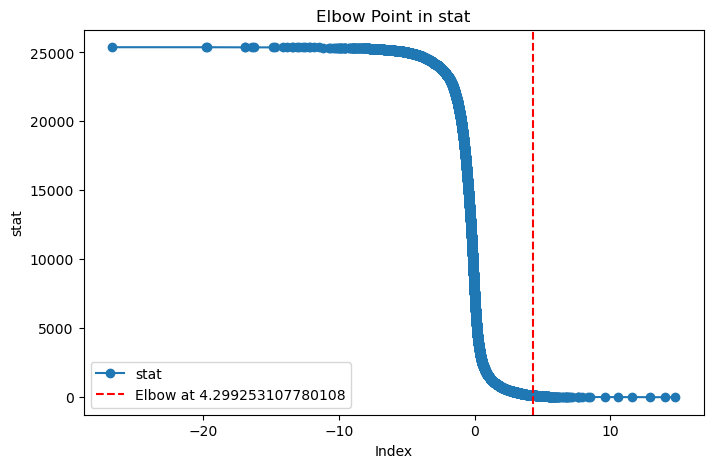

In [9]:
lfc_elbow = plot_lfc_elbow(df_dds_dict['yo_file'])

yo_file: 305 genes
ym_file: 175 genes
mo_file: 2065 genes
yo_F_file: 612 genes
yo_M_file: 143 genes
ym_F_file: 60 genes
ym_M_file: 79 genes
mo_F_file: 272 genes
mo_M_file: 1332 genes
mf_y_file: 62 genes
mf_m_file: 1101 genes
mf_o_file: 0 genes


/tmp/ipykernel_1862/2310334656.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


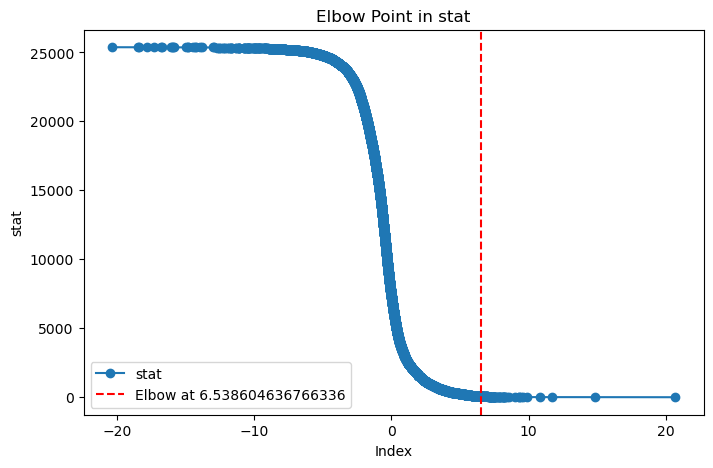

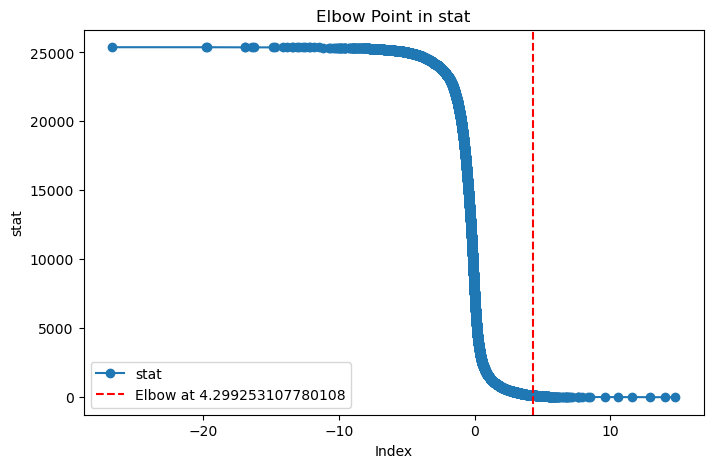

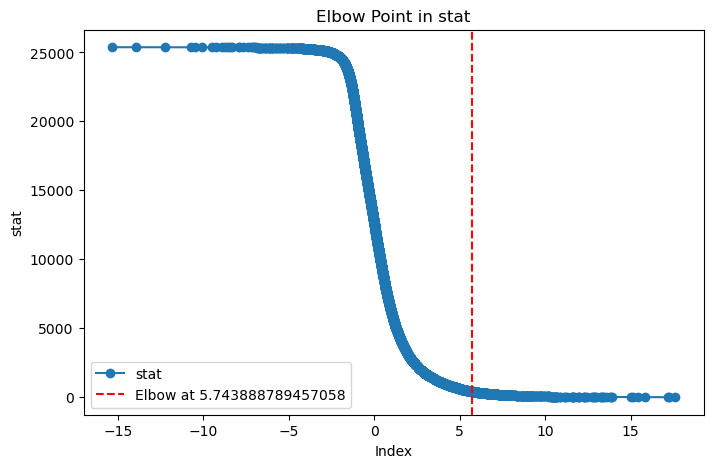

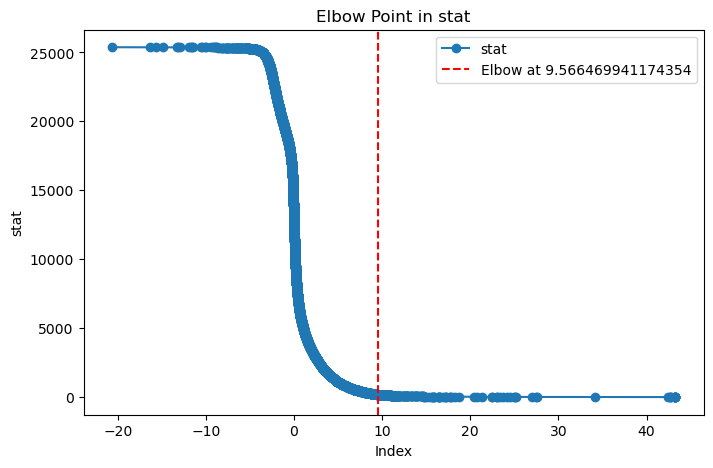

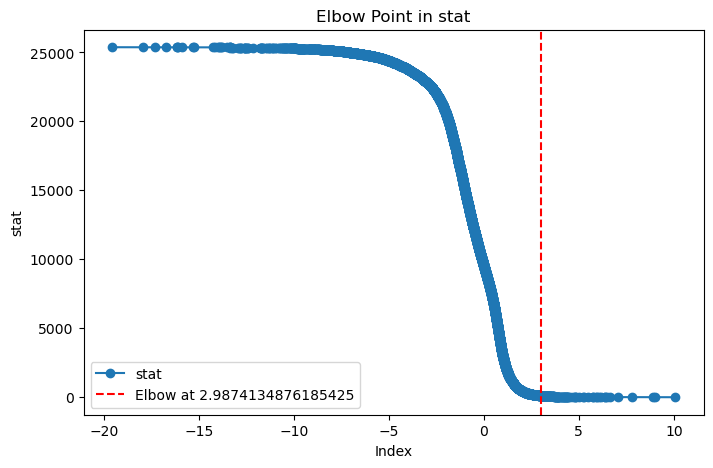

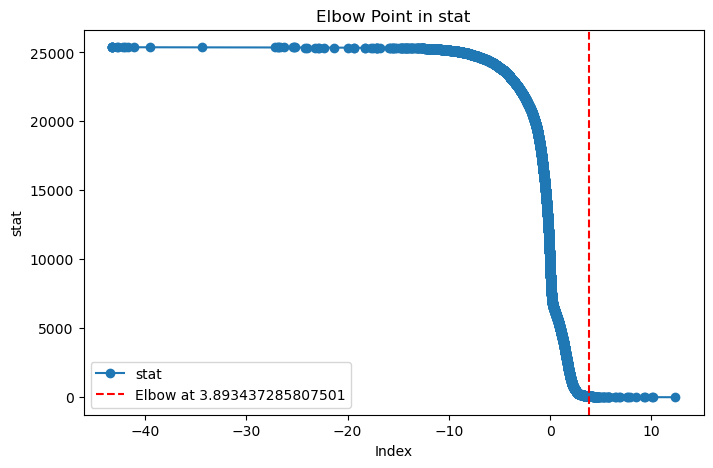

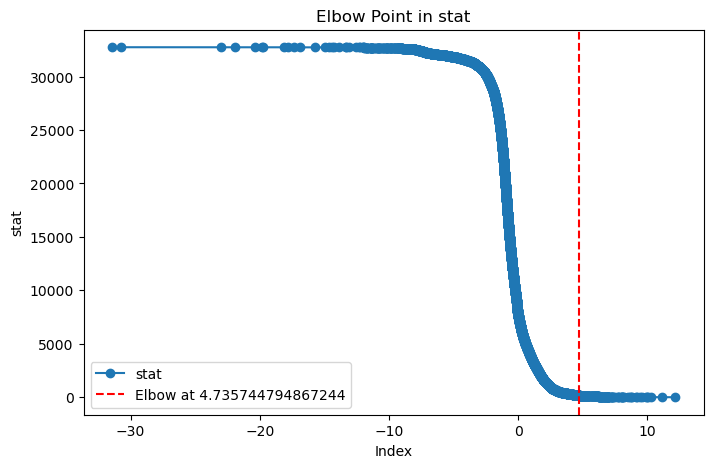

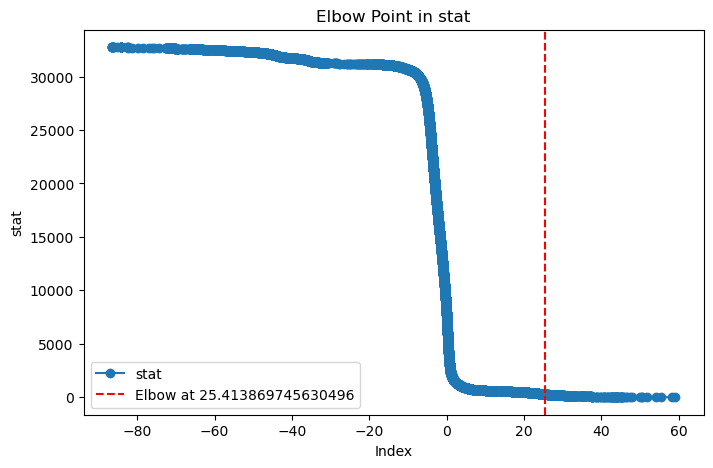

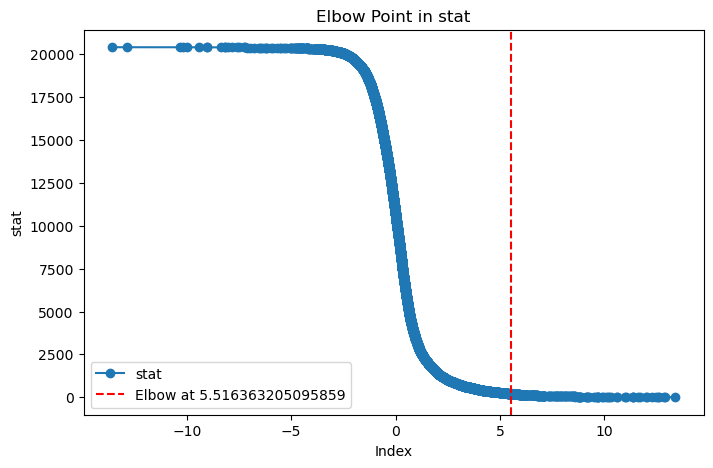

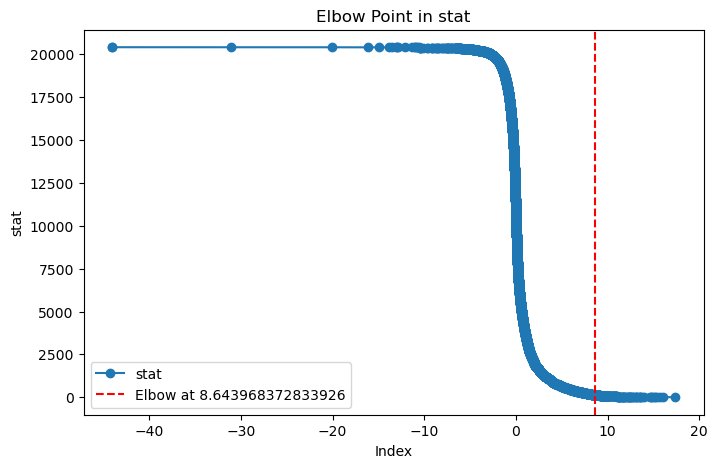

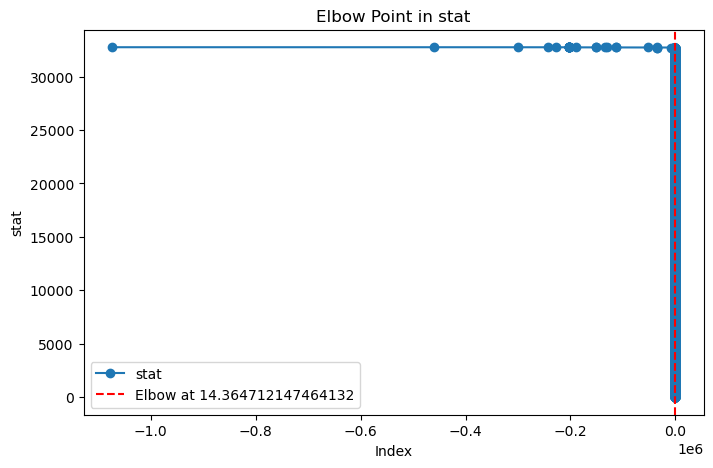

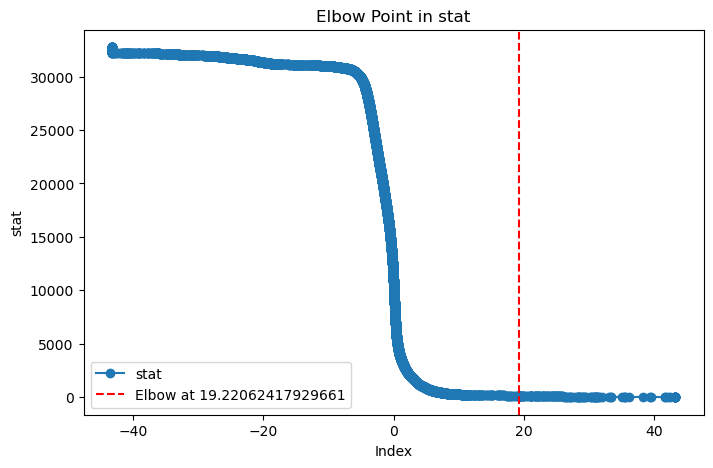

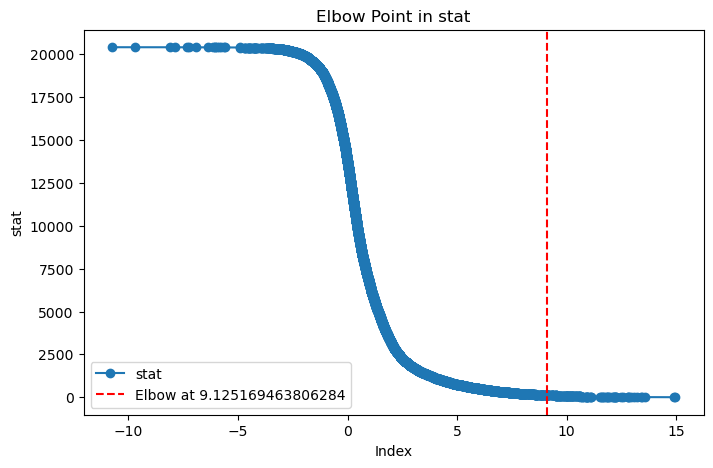

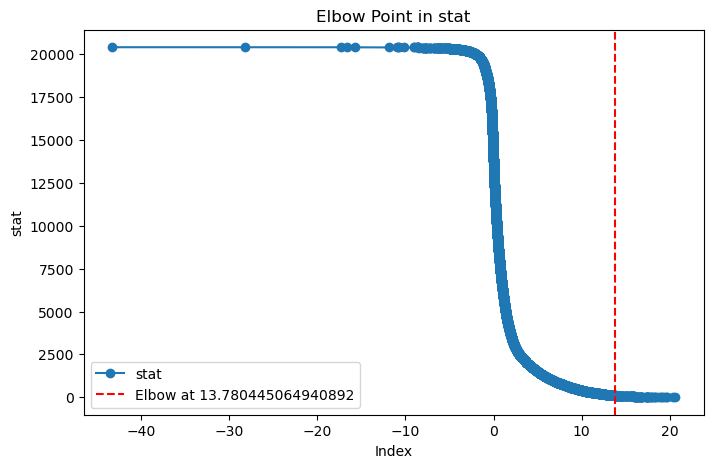

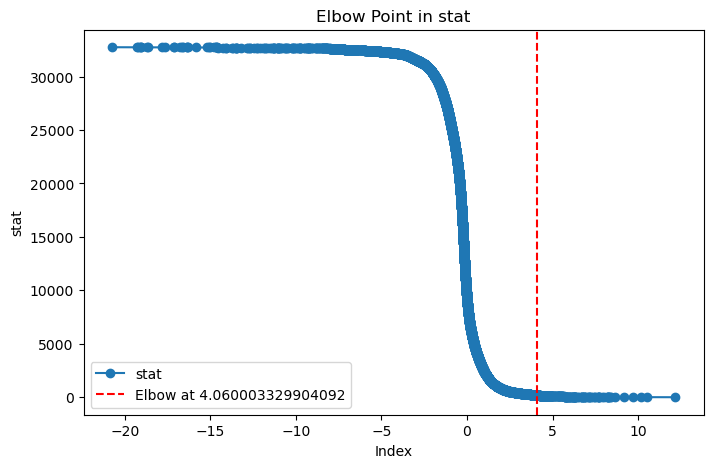

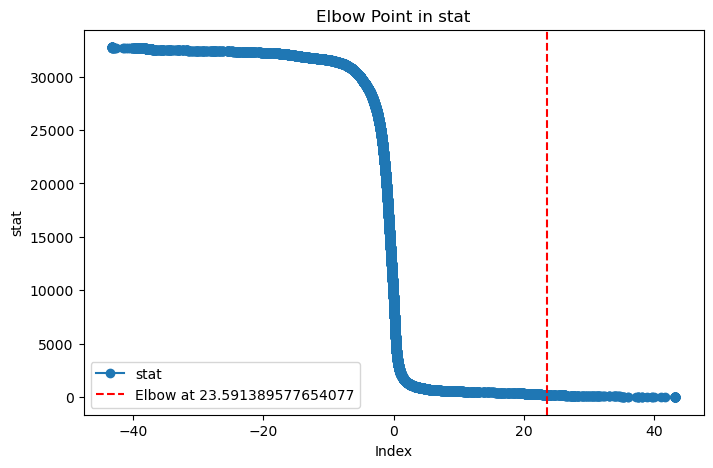

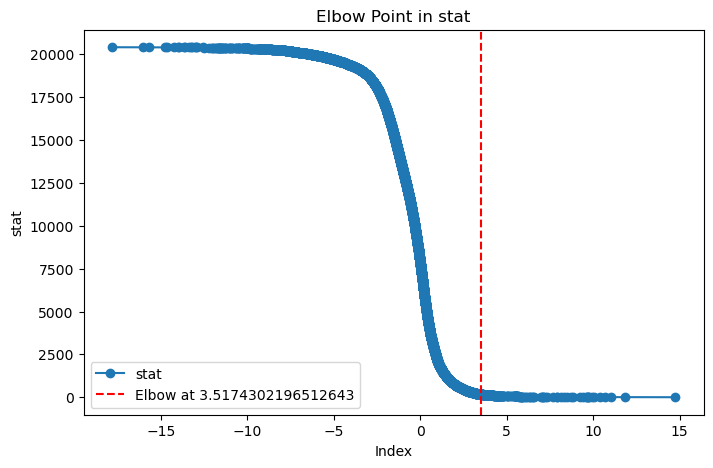

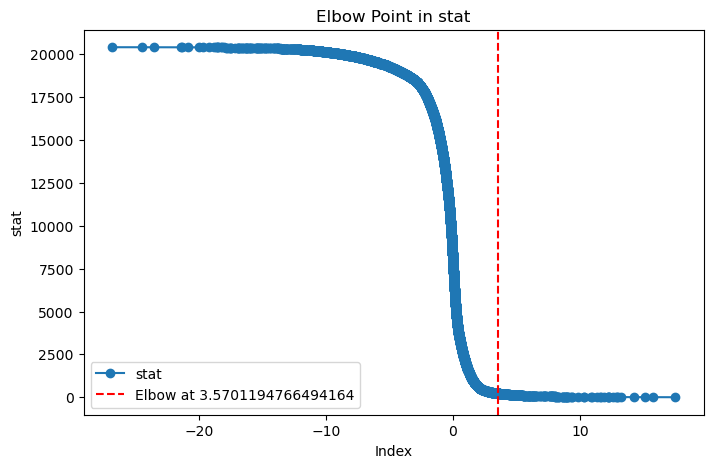

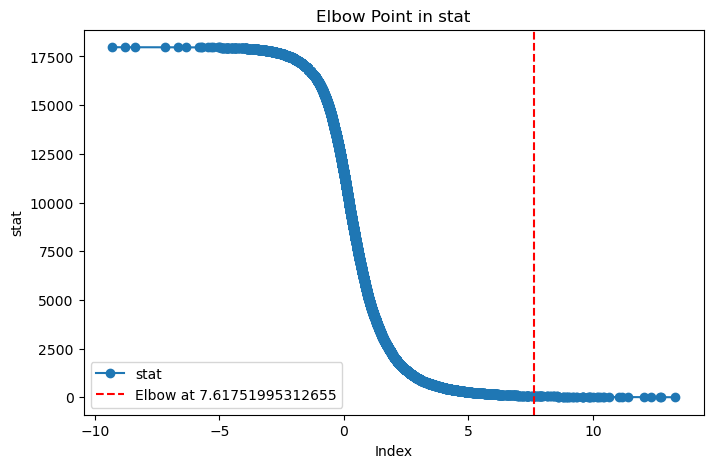

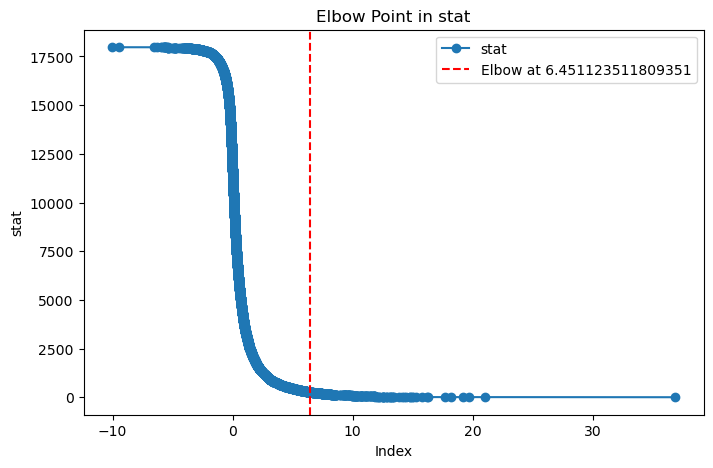

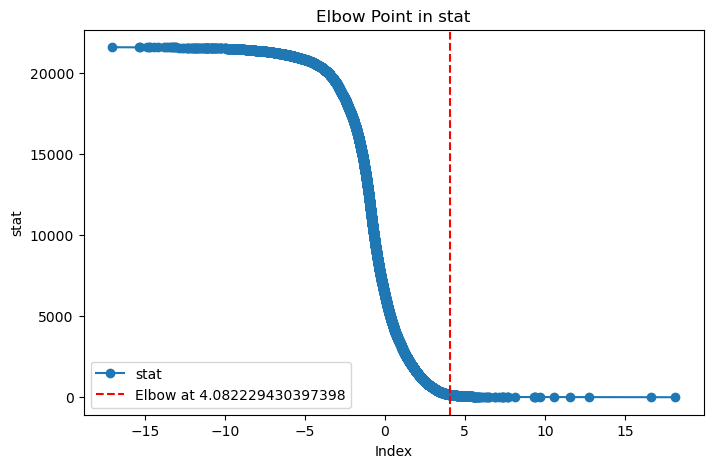

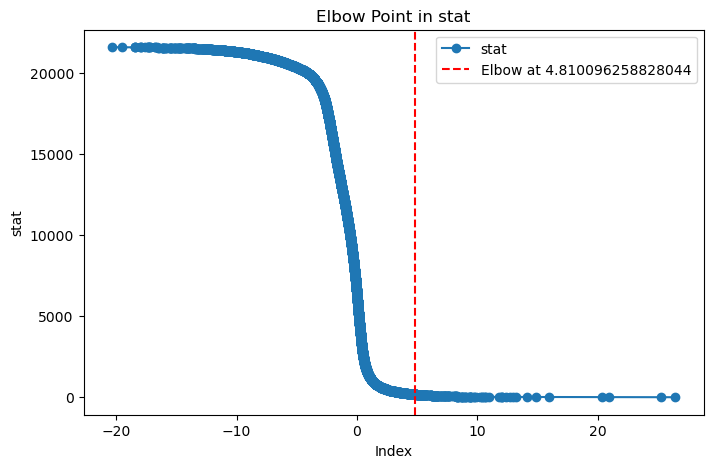

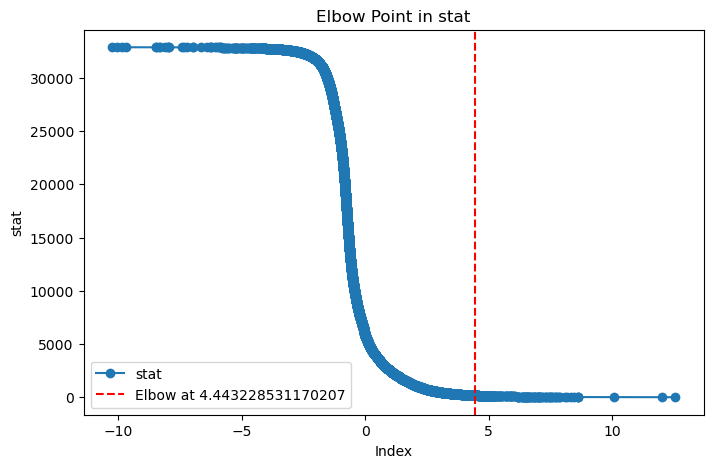

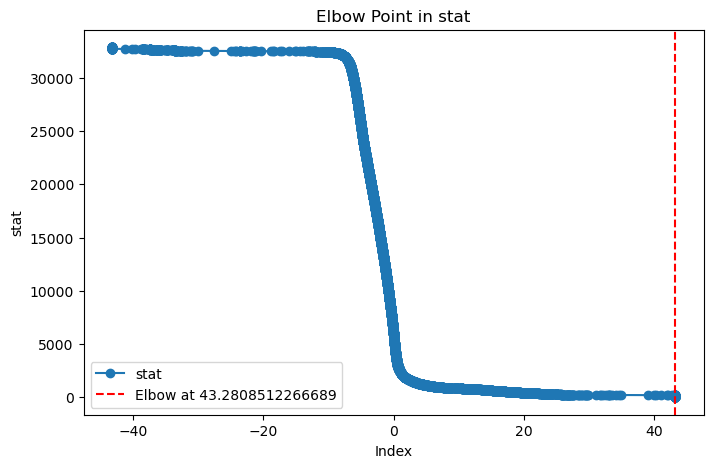

In [13]:
for comparison in df_dds_dict:
    results_df =df_dds_dict[comparison]
    elbow_point=plot_ORA(results_df)
    elbow = elbow_point
    dds_de = results_df[(abs(results_df['stat'])>elbow) & (results_df['padj']<pvalue)]
    lfc_elbow = plot_lfc_elbow(df_dds_dict[comparison])
    dds_de = dds_de[abs(dds_de['log2FoldChange'])>lfc_elbow]
    dds_de.to_csv(f"results/ de_genes_{comparison}.csv")
    dds_de.sort_values(by='log2FoldChange')
    top_genes = list(dds_de[dds_de['padj'] < pvalue].index)
    print(comparison +": " + str(len(top_genes))+" genes")
    enr_pvals = dc.get_ora_df(
    df=top_genes,#[:10],
    net=msigdb,
    source='geneset',
    target='genesymbol'
    )
    enr_pvals.to_csv(f'/home/amore/work/data/All_{comparison}_ORA.csv', header=True)
    significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.1) & (enr_pvals["FDR p-value"] < 0.15)]
    if significant_ORA.shape[0] >0:
        print(f"{comparison} has {significant_ORA.shape[0]} pathways")
    

    
    

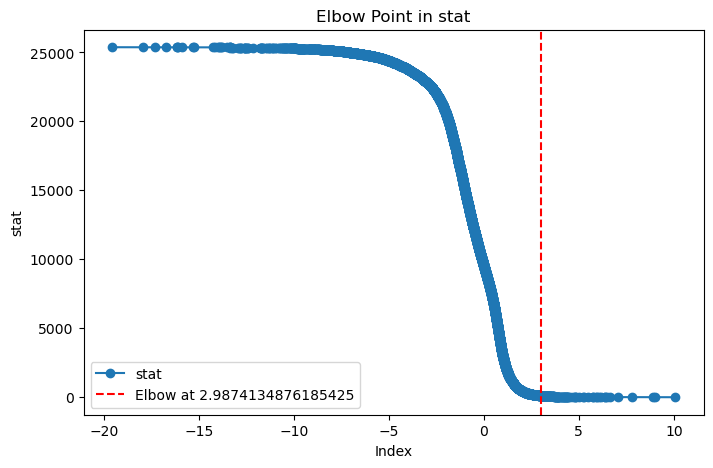

In [41]:
elbow_point

2.9874134876185425

In [42]:
### get elbow point


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Unnamed: 31302,6.421005e+06,-34.407073,5.652896,-6.086628,1.153136e-09,4.885523e-08
GIMAP1-GIMAP5,1.205429e+07,-27.155545,1.514770,-17.927173,7.236740e-72,9.182699e-68
TMEM187,1.132096e+06,-26.828430,1.370715,-19.572574,2.649545e-85,6.724016e-81
Unnamed: 33813,3.666245e+06,-26.823052,1.667707,-16.083791,3.314586e-58,1.201680e-54
Unnamed: 32081,8.649072e+05,-26.677513,1.995700,-13.367497,9.363873e-41,1.250718e-37
...,...,...,...,...,...,...
NDUFB4,8.215766e+05,9.273909,1.028417,9.017655,1.921589e-19,3.340142e-17
GPX7,3.443875e+04,9.379588,0.930069,10.084828,6.447779e-24,2.045397e-21
RPL12P13,3.999909e+04,10.089088,1.585216,6.364488,1.959421e-10,9.435708e-09
MTCO1P24,8.601578e+04,10.115922,1.432533,7.061565,1.646377e-12,1.090907e-10


2691

In [ ]:
dds

In [ ]:
top_genes[:3]

In [ ]:
list(dds.index)

In [44]:
# Infer enrichment with ora using significant deg

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,#[:10],
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.081818,0.968440,1.0,0.637481,0.020443,CACNA1C;COL23A1;DTNA;KCND2;MMD;PRIMA1;TAF9B;TT...
1,AAAGACA_MIR511,204,0.049020,0.999985,1.0,0.379059,0.000006,AQP6;CAMK2N1;CCDC178;CEP350;ENPP1;PAX8;PMEPA1;...
2,AAAGGAT_MIR501,127,0.062992,0.996862,1.0,0.493721,0.001552,CCDC140;CUL1;KCND2;KCNRG;MYCL;PLXNB1;RAB22A;SL...
3,AAAGGGA_MIR204_MIR211,224,0.053571,0.999979,1.0,0.410950,0.000009,AP1S1;CELSR3;CRKL;DTX1;DVL3;EDEM1;EPHA7;GRM1;P...
4,AAANWWTGC_UNKNOWN,194,0.056701,0.999872,1.0,0.436888,0.000056,ATOH7;CACNG3;EPHA7;GPC6;HOXC4;MRPS18B;MYCL;PRI...


In [45]:
enr_pvals.to_csv(f'/home/amore/work/data/All_{comparison}_ORA.csv', header=True)

In [46]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.1) & (enr_pvals["FDR p-value"] < 0.15)]
significant_ORA

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features


In [ ]:
dc.plot_dotplot(
    significant_ORA.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='p-value',
    scale=.5,
    figsize=(5, 10)
)

### GSEA vs ORA

In [ ]:
enr_gsea[enr_gsea['Term'].isin(significant_ORA['Term'])].sort_values(by="NES")

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_MITOCHONDRIA'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='kegg_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='KEGG_OXIDATIVE_PHOSPHORYLATION'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_DNA_TEMPLATED_DNA_REPLICATION_MAINTENANCE_OF_FIDELITY'
)



In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='reactome_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SYNTHESIS_BY_CHEMIOSMOTIC_COUPLING_AND_HEAT_PRODUCTION_BY_UNCOUPLING_PROTEINS'
)



In [ ]:
set(msigdb["collection"])